# Cetacean MLP — Calibrated LODO (Vector Scaling + PR-Threshold + Consensus)

Five prediction strategies compared in LODO:

- **argmax** — standard softmax argmax (baseline)
- **vec** — vector scaling: per-class `w_c * logit_c + b_c`, fit on full val with class weighting
- **pr_thresh** — per-species F1-optimal threshold fit on val via precision-recall curve;
  argmax among species that clear their threshold, fallback to background if none do
- **con2** — consensus of ≥2 of {argmax, vec, pr_thresh}; if no label has ≥2 votes → background
- **con3** — unanimous consensus: all three of {argmax, vec, pr_thresh} agree, else → background

Consensus is computed per-row by majority vote over the three base integer predictions
(`y_argmax`, `y_vec`, `y_pr_thresh`). A tie with no ≥2 majority resolves to background — the
conservative non-detection fallback.

### Inter-species confusion definition
A prediction counts as inter-species confusion if the true label is a species and
the predicted label is ANY species in the training vocabulary.
`sp_hallucination_rate` = fraction of species test rows where prediction is a species
absent from the test fold entirely.

**Rule:** the test set is never used for calibration or threshold fitting.

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [2]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo_Best_version')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo_Best_version


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')

EXCLUDE = {'ALNITAK_CAVANILLES', 'FREMANTLE', 'ECOSS_enhanced'}
meta_all = meta_all[~meta_all['dataset'].isin(EXCLUDE)].reset_index(drop=True)

print(f"meta_all: {len(meta_all):,} rows")

# sanity check: row values must still be valid X_all indices
assert meta_all['row'].max() < len(X_all)
assert meta_all['row'].min() >= 0
assert meta_all['row'].nunique() == len(meta_all), "duplicate row indices — unexpected"


meta_all: 241,928 rows


In [4]:

print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

X_all:    (247630, 1536)  dtype=float32
datasets (9): ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Label frames

In [5]:
def build_l2(row):
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('odontocete','mysticete','anthropogenic','background'):
        return t2
    t1 = row['label_t1']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    return None

def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l2 = meta_all.copy(); meta_l2['label'] = meta_l2.apply(build_l2, axis=1)
meta_l2 = meta_l2.dropna(subset=['label']).copy()
print(f"\nL2: {len(meta_l2):,} rows"); print(meta_l2['label'].value_counts().to_string())

meta_l4 = meta_all.copy(); meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows"); print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())


L2: 241,928 rows
label
background       175362
anthropogenic     33871
odontocete        32139
mysticete           556

L4: 241,928 rows
label
background                    209233
Orcinus_orca                   21794
Tursiops_truncatus              6833
Delphinus_delphis               1292
Physeter_macrocephalus           895
Globicephala_melas               580
Balaenoptera_physalus            539
Delphinidae_unknown              466
Grampus_griseus                  194
Stenella_coeruleoalba             85
Balaenoptera_acutorostrata        17

label            Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                                                                                            

## 2. MLP

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)   # raw logits


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3, lr=1e-3, weight_decay=1e-4,
              batch_size=1024, epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 3. Calibrators


### Vector scaling
`softmax(w * logits + b)` — per-class scale and bias.  
**L4 / L2:** fit on species-positive val rows only (removes background dominance).  
**L1 binary:** fit on full val — species-only filtering degenerates when there
are only 2 classes (one of which IS the species class).

In [7]:
class VectorScaler(nn.Module):
    """
    Per-class scale + bias: calibrated_logit_c = w_c * logit_c + b_c
    Optimized across ALL validation data using inverse frequency weighting 
    to handle class imbalance without discarding background profiles.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))   # init: identity
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, logits):
        return logits * self.w + self.b

    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        """
        logits_val : (N, C) val logits
        y_val      : (N,) integer labels
        l2         : L2 regularisation pulling w→1, b→0
        """
        # Do NOT filter out background rows. Convert the complete validation set to tensors.
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)

        # Calculate class weights directly from the validation labels to counter imbalance
        counts = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        class_weights_t = torch.tensor(weights, dtype=torch.float32)

        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)

        def closure():
            opt.zero_grad()
            cal_logits = self.forward(logits_t)
            
            # Use class weights here so rare species are balanced against the background class
            nll = F.cross_entropy(cal_logits, labels_t, weight=class_weights_t)
            
            # L2 regularisation: keep w close to 1, b close to 0
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            loss = nll + reg
            loss.backward()
            return loss

        opt.step(closure)
        return self

def calibrate_and_predict(logits, calibrator):
    with torch.no_grad():
        cal = calibrator(torch.tensor(logits, dtype=torch.float32))
        proba = F.softmax(cal, dim=1).numpy()
    return proba.argmax(axis=1), proba

## 4. Metrics

### Corrected inter-species confusion

A prediction is counted as inter-species confusion if:
- true label is a **species** (not background), AND
- predicted label is **any species in the training vocabulary** — including
  species with zero rows in the test fold.

Additionally: `sp_hallucination_rate` = fraction of species test rows where
the model predicted a species that has **zero true positives in this test fold**.
This is the worst deployment error: confidently asserting a species that is
entirely absent from the recording context.

In [8]:
def compute_metrics(y_true, y_pred, labels_present, n_classes):
    all_labels = list(range(n_classes))
    return {
        'test_macro_f1':            float(f1_score(y_true, y_pred, average='macro',
                                                   labels=labels_present, zero_division=0)),
        'test_macro_f1_full_vocab': float(f1_score(y_true, y_pred, average='macro',
                                                   labels=all_labels, zero_division=0)),
        'test_weighted_f1':         float(f1_score(y_true, y_pred, average='weighted',
                                                   labels=labels_present, zero_division=0)),
        'test_accuracy':            float(accuracy_score(y_true, y_pred)),
        'test_balanced_acc':        float(balanced_accuracy_score(y_true, y_pred)),
    }


def compute_species_metrics(y_true, y_pred, class_names, bg_label):
    """
    Metrics on species-only test rows (true label != background).

    Inter-species confusion: predicted ANY species in the training vocab
    but it was the wrong one — including species absent from the test fold.

    Hallucination rate: predicted a species that has ZERO true positives
    in this test fold (model asserts a species that isn't there at all).
    """
    bg_idx     = class_names.index(bg_label) if bg_label in class_names else -1
    # All species indices in the FULL training vocabulary
    all_sp_idx = set(i for i, c in enumerate(class_names) if i != bg_idx)

    sp_mask    = (y_true != bg_idx)
    sp_present = sorted(np.unique(y_true[sp_mask]).tolist())   # test-present only
    sp_absent  = all_sp_idx - set(sp_present)                  # in vocab but not in test

    if sp_mask.sum() == 0:
        return {k: None for k in [
            'sp_macro_f1','sp_recall','sp_precision','sp_balanced_acc',
            'sp_inter_confusion_rate','sp_hallucination_rate','sp_n_rows'
        ]}

    yt = y_true[sp_mask]
    yp = y_pred[sp_mask]
    n  = len(yt)

    # Inter-species confusion: wrong species predicted (vocab-wide)
    inter_conf   = float(((yp != yt) & np.isin(yp, list(all_sp_idx))).sum() / n)

    # Hallucination: predicted a species absent from this test fold
    hallucination = float(np.isin(yp, list(sp_absent)).sum() / n)

    return {
        'sp_macro_f1':             float(f1_score(yt, yp, average='macro',
                                                  labels=sp_present, zero_division=0)),
        'sp_recall':               float(recall_score(yt, yp, average='macro',
                                                      labels=sp_present, zero_division=0)),
        'sp_precision':            float(precision_score(yt, yp, average='macro',
                                                         labels=sp_present, zero_division=0)),
        'sp_balanced_acc':         float(balanced_accuracy_score(yt, yp)),
        'sp_inter_confusion_rate': inter_conf,
        'sp_hallucination_rate':   hallucination,
        'sp_n_rows':               int(n),
    }


def per_class_f1(y_true, y_pred, class_names):
    n   = len(class_names)
    f1s = f1_score(y_true, y_pred, labels=list(range(n)), average=None, zero_division=0)
    return {class_names[i]: float(f1s[i]) for i in range(n)}

## 5. LODO runner

## 3b. PR-threshold calibrator

For each species class, sweep all unique probability values on the val set
and pick the threshold that maximises per-class F1.
At inference, a row is assigned the highest-scoring species that clears its threshold;
if no species qualifies the row falls back to background.

In [9]:
from sklearn.metrics import precision_recall_curve

def fit_pr_thresholds(proba_val, y_val, class_names, bg_idx, min_thr=0.01):
    """
    Fit per-species F1-optimal thresholds on val probabilities.
    Returns dict: class_name -> threshold.
    Background gets threshold 0.0 (always qualifies as fallback).
    """
    thresholds = {}
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            thresholds[cls_name] = 0.0
            continue
        y_bin = (y_val == cls_idx).astype(int)
        if y_bin.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        precs, recs, thrs = precision_recall_curve(y_bin, proba_val[:, cls_idx])
        f1s  = 2 * precs * recs / np.clip(precs + recs, 1e-9, None)
        f1s  = f1s[:-1]   # trailing point has no threshold
        valid = thrs >= min_thr
        if valid.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        best = np.argmax(f1s[valid])
        thresholds[cls_name] = float(thrs[valid][best])
    return thresholds


def predict_with_pr_thresholds(proba, class_names, thresholds, bg_idx):
    """
    For each row: take argmax among classes that exceed their threshold.
    If nothing qualifies, fall back to background.
    """
    qualify = np.zeros(proba.shape, dtype=bool)
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            qualify[:, cls_idx] = True   # bg always qualifies as fallback
            continue
        thr = thresholds.get(cls_name, 0.5)
        qualify[:, cls_idx] = proba[:, cls_idx] >= thr
    masked = np.where(qualify, proba, -np.inf)
    return masked.argmax(axis=1)


In [10]:
def consensus_vote(y_a, y_v, y_p, bg_idx):
    """
    Majority vote over three integer prediction arrays.

    con2 : label held by >= 2 of the three voters; if all three disagree
           (no majority) -> bg_idx (conservative non-detection).
    con3 : label only if ALL three agree; otherwise -> bg_idx.

    Vectorised, no per-row Python loop.
    """
    y_a = np.asarray(y_a); y_v = np.asarray(y_v); y_p = np.asarray(y_p)
    fallback = bg_idx if bg_idx >= 0 else 0

    av = (y_a == y_v)
    ap = (y_a == y_p)
    vp = (y_v == y_p)

    # con3: unanimous
    unanimous = av & ap            # if a==v and a==p then v==p too
    y_con3 = np.where(unanimous, y_a, fallback)

    # con2: at least one matching pair carries the majority label.
    # Priority a==v, then a==p, then v==p (all matching pairs share the
    # same label whenever >=2 agree, so order only matters for which
    # source array we read from — the value is identical).
    y_con2 = np.full_like(y_a, fallback)
    y_con2 = np.where(vp, y_v, y_con2)
    y_con2 = np.where(ap, y_a, y_con2)
    y_con2 = np.where(av, y_a, y_con2)
    return y_con2, y_con3


def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def run_calibrated_lodo(held_out, meta_df, label_col='label',
                        bg_label='background', species_only_fit=True,
                        min_train_per_class=5, val_size=0.12, verbose=True):
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep

    if verbose:
        print(f"\n  [{held_out}] train classes ({len(train_keep)}): {sorted(train_keep)}")
        print(f"  [{held_out}] test composition:")
        for c, n in test_meta[label_col].value_counts().items():
            mark = 'OK' if c in train_keep else 'NOT in train — dropped'
            print(f"      {c:35s} n={n:>6,}  ({mark})")

    if len(train_keep) < 2: return None
    if len(test_keep)  < 1: return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))
    Xte_s = sc.transform(np.asarray(X_all[rows_te], dtype=np.float32))
    ytr   = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva   = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte   = test_meta['y'].values

    sp_rows_val = int((yva != bg_idx).sum()) if bg_idx >= 0 else len(yva)
    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  "
              f"(sp_val={sp_rows_val:,})  test={len(rows_te):,}")

    t0             = time.time()
    model, best_va = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed        = time.time() - t0

    logits_va = get_logits(model, Xva_s)
    logits_te = get_logits(model, Xte_s)

    # A: argmax
    proba_raw = torch.softmax(torch.tensor(logits_te), dim=1).numpy()
    y_argmax  = proba_raw.argmax(axis=1)

    # B: vector scaling
    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3)
    y_vec, proba_vec = calibrate_and_predict(logits_te, vec_scaler)

    # C: PR-threshold (fit on raw val probs)
    proba_va_raw  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
    pr_thresholds = fit_pr_thresholds(proba_va_raw, yva, class_names, bg_idx)
    y_pr_thresh   = predict_with_pr_thresholds(proba_raw, class_names, pr_thresholds, bg_idx)

    # D & E: consensus over {argmax, vec, pr_thresh}
    #   con2 = label with >=2 votes, else background (no majority -> non-detection)
    #   con3 = label only if all three agree, else background
    y_con2, y_con3 = consensus_vote(y_argmax, y_vec, y_pr_thresh, bg_idx)

    if verbose:
        print(f"  [{held_out}] vector scales:")
        for cn, w, b in zip(class_names,
                            vec_scaler.w.detach().numpy(),
                            vec_scaler.b.detach().numpy()):
            print(f"      {cn:35s}  w={w:+.3f}  b={b:+.3f}")
        print(f"  [{held_out}] PR thresholds:")
        for cn, t in sorted(pr_thresholds.items(), key=lambda kv: kv[1]):
            n_val = int((yva == class_names.index(cn)).sum()) if cn in class_names else 0
            print(f"      {cn:35s}  thr={t:.3f}  n_val={n_val}")

    present = sorted(np.unique(yte).tolist())

    return {
        'held_out':              held_out,
        'class_names':           class_names,
        'n_classes':             n_cls,
        'bg_idx':                bg_idx,
        'n_train':               len(rows_tr),
        'n_val':                 len(rows_va),
        'n_val_species':         sp_rows_val,
        'n_test':                len(rows_te),
        'rows_te':               rows_te,
        'val_macro_f1':          float(best_va),
        'elapsed_s':             float(elapsed),
        'vec_w':                 vec_scaler.w.detach().numpy().copy(),
        'vec_b':                 vec_scaler.b.detach().numpy().copy(),
        'pr_thresholds':         pr_thresholds,
        'yte':                   yte,
        'y_argmax':              y_argmax,
        'y_vec':                 y_vec,
        'y_pr_thresh':           y_pr_thresh,
        'y_con2':                y_con2,
        'y_con3':                y_con3,
        'proba_raw':             proba_raw,
        'proba_vec':             proba_vec,
        'metrics_argmax':        compute_metrics(yte, y_argmax,    present, n_cls),
        'metrics_vec':           compute_metrics(yte, y_vec,       present, n_cls),
        'metrics_pr_thresh':     compute_metrics(yte, y_pr_thresh, present, n_cls),
        'metrics_con2':          compute_metrics(yte, y_con2,      present, n_cls),
        'metrics_con3':          compute_metrics(yte, y_con3,      present, n_cls),
        'sp_argmax':             compute_species_metrics(yte, y_argmax,    class_names, bg_label),
        'sp_vec':                compute_species_metrics(yte, y_vec,       class_names, bg_label),
        'sp_pr_thresh':          compute_species_metrics(yte, y_pr_thresh, class_names, bg_label),
        'sp_con2':               compute_species_metrics(yte, y_con2,      class_names, bg_label),
        'sp_con3':               compute_species_metrics(yte, y_con3,      class_names, bg_label),
        'pc_f1_argmax':          per_class_f1(yte, y_argmax,    class_names),
        'pc_f1_vec':             per_class_f1(yte, y_vec,       class_names),
        'pc_f1_pr_thresh':       per_class_f1(yte, y_pr_thresh, class_names),
        'pc_f1_con2':            per_class_f1(yte, y_con2,      class_names),
        'pc_f1_con3':            per_class_f1(yte, y_con3,      class_names),
        'test_classes_present':  present,
        'model':                 model,
        'scaler':                sc,
        'vec_scaler':            vec_scaler,
    }


def run_lodo_level(meta_df, label_col, level_name, holdouts,
                   bg_label='background', species_only_fit=True,
                   min_train_per_class=5, val_size=0.12, verbose=True):
    results = {}
    for ds in tqdm(holdouts, desc=f'{level_name} LODO'):
        r = run_calibrated_lodo(
            ds, meta_df, label_col=label_col, bg_label=bg_label,
            species_only_fit=species_only_fit,
            min_train_per_class=min_train_per_class,
            val_size=val_size, verbose=verbose)
        if r is not None:
            results[ds] = r
    return results


## 6. Summary and plotting helpers

In [11]:
def make_summary_df(results, level_name):
    rows = []
    for ds, r in results.items():
        ma = r['metrics_argmax'];  mv = r['metrics_vec'];   mp = r['metrics_pr_thresh']
        m2 = r['metrics_con2'];    m3 = r['metrics_con3']
        sa = r['sp_argmax'];       sv = r['sp_vec'];        sp = r['sp_pr_thresh']
        s2 = r['sp_con2'];         s3 = r['sp_con3']
        rows.append({
            'level':                level_name,
            'held_out':             ds,
            'n_test':               r['n_test'],
            'n_val_species':        r['n_val_species'],
            'n_classes_test':       len(r['test_classes_present']),
            # macro F1 (test classes)
            'argmax_macro_f1':      ma['test_macro_f1'],
            'vec_macro_f1':         mv['test_macro_f1'],
            'pr_thresh_macro_f1':   mp['test_macro_f1'],
            'con2_macro_f1':        m2['test_macro_f1'],
            'con3_macro_f1':        m3['test_macro_f1'],
            'delta_vec':            mv['test_macro_f1'] - ma['test_macro_f1'],
            'delta_pr_thresh':      mp['test_macro_f1'] - ma['test_macro_f1'],
            'delta_con2':           m2['test_macro_f1'] - ma['test_macro_f1'],
            'delta_con3':           m3['test_macro_f1'] - ma['test_macro_f1'],
            # species recall
            'argmax_sp_recall':     sa.get('sp_recall'),
            'vec_sp_recall':        sv.get('sp_recall'),
            'pr_thresh_sp_recall':  sp.get('sp_recall'),
            'con2_sp_recall':       s2.get('sp_recall'),
            'con3_sp_recall':       s3.get('sp_recall'),
            # species precision
            'argmax_sp_prec':       sa.get('sp_precision'),
            'vec_sp_prec':          sv.get('sp_precision'),
            'pr_thresh_sp_prec':    sp.get('sp_precision'),
            'con2_sp_prec':         s2.get('sp_precision'),
            'con3_sp_prec':         s3.get('sp_precision'),
            # species F1
            'argmax_sp_f1':         sa.get('sp_macro_f1'),
            'vec_sp_f1':            sv.get('sp_macro_f1'),
            'pr_thresh_sp_f1':      sp.get('sp_macro_f1'),
            'con2_sp_f1':           s2.get('sp_macro_f1'),
            'con3_sp_f1':           s3.get('sp_macro_f1'),
            # inter-species confusion
            'argmax_inter_conf':    sa.get('sp_inter_confusion_rate'),
            'vec_inter_conf':       sv.get('sp_inter_confusion_rate'),
            'pr_thresh_inter_conf': sp.get('sp_inter_confusion_rate'),
            'con2_inter_conf':      s2.get('sp_inter_confusion_rate'),
            'con3_inter_conf':      s3.get('sp_inter_confusion_rate'),
            # hallucination
            'argmax_hallucin':      sa.get('sp_hallucination_rate'),
            'vec_hallucin':         sv.get('sp_hallucination_rate'),
            'pr_thresh_hallucin':   sp.get('sp_hallucination_rate'),
            'con2_hallucin':        s2.get('sp_hallucination_rate'),
            'con3_hallucin':        s3.get('sp_hallucination_rate'),
            'sp_n_rows':            sa.get('sp_n_rows', 0),
        })
    return pd.DataFrame(rows).sort_values('pr_thresh_sp_f1', ascending=False, na_position='last')

def per_class_delta_heatmap(results, strategy_key, base_key,
                             title, out_path, bg_label='background'):
    delta_rows = []
    for ds, r in results.items():
        class_names = r['class_names']
        present     = set(r['test_classes_present'])
        f1_base     = r[f'pc_f1_{base_key}']
        f1_strat    = r[f'pc_f1_{strategy_key}']
        for c_idx, c_name in enumerate(class_names):
            if c_idx not in present:
                delta_rows.append({'held_out': ds, 'class': c_name, 'delta': np.nan})
            else:
                delta_rows.append({
                    'held_out': ds, 'class': c_name,
                    'delta':    f1_strat[c_name] - f1_base[c_name],
                })
    df          = pd.DataFrame(delta_rows)
    delta_pivot = df.pivot(index='held_out', columns='class', values='delta')
    sp_cols     = [c for c in delta_pivot.columns if c != bg_label]
    sp_sorted   = delta_pivot[sp_cols].mean(skipna=True).sort_values().index.tolist()
    col_order   = sp_sorted + ([bg_label] if bg_label in delta_pivot.columns else [])
    delta_pivot = delta_pivot[col_order]
    vabs  = max(np.nanmax(np.abs(delta_pivot.values)), 0.01)
    annot = delta_pivot.copy().round(3).astype(str)
    annot[delta_pivot.isna()] = '—'
    fig, ax = plt.subplots(figsize=(max(10, 0.8*len(delta_pivot.columns)+2),
                                    max(5,  0.5*len(delta_pivot)+1.5)))
    sns.heatmap(delta_pivot, cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
                annot=annot, fmt='', linewidths=0.3, ax=ax,
                mask=delta_pivot.isna(),
                cbar_kws={'label': f'ΔF1 ({strategy_key} − {base_key})'})
    ax.set_facecolor('#e8e8e8')
    ax.set_title(title, fontsize=10)
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    ax.set_xlabel('class'); ax.set_ylabel('held-out dataset')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMean ΔF1 per class ({strategy_key} − {base_key}):")
    print(delta_pivot.mean(skipna=True).round(3).sort_values().to_string())
    return df


def report_fold(r, bg_label='background'):
    ds            = r['held_out']
    class_names   = r['class_names']
    present       = r['test_classes_present']
    present_names = [class_names[i] for i in present]
    n_cls         = r['n_classes']

    STRATS = [('argmax', 'metrics_argmax', 'sp_argmax', 'y_argmax'),
              ('vec',    'metrics_vec',    'sp_vec',    'y_vec'),
              ('pr_thr', 'metrics_pr_thresh','sp_pr_thresh','y_pr_thresh'),
              ('con2',   'metrics_con2',   'sp_con2',   'y_con2'),
              ('con3',   'metrics_con3',   'sp_con3',   'y_con3')]

    print(f"\n{'='*94}")
    print(f"  {ds}  |  classes: {present_names}")
    print(f"{'='*94}")
    hdr = f"  {'metric':38s}" + ''.join(f"  {s[0]:>8s}" for s in STRATS)
    print(hdr)
    print(f"  {'-'*(38+10*len(STRATS))}")
    for key, label in [
        ('test_macro_f1',     'macro F1 (test classes)'),
        ('test_balanced_acc', 'balanced accuracy'),
    ]:
        line = f"  {label:38s}"
        for _, mk, _, _ in STRATS:
            line += f"  {r[mk][key]:>8.3f}"
        print(line)
    print(f"  {'--- species rows only ---':38s}")
    for key, label in [
        ('sp_recall',               'species recall (macro)'),
        ('sp_precision',            'species precision (macro)'),
        ('sp_macro_f1',             'species macro F1'),
        ('sp_inter_confusion_rate', 'inter-species confusion'),
        ('sp_hallucination_rate',   'hallucination rate'),
    ]:
        if r['sp_argmax'].get(key) is None:
            continue
        line = f"  {label:38s}"
        for _, _, sk, _ in STRATS:
            val = r[sk].get(key)
            line += f"  {val:>8.3f}" if val is not None else f"  {'—':>8s}"
        print(line)

    if n_cls <= 15:
        ncols = len(STRATS)
        fig, axes = plt.subplots(1, ncols,
                                 figsize=(min(30, 0.6*n_cls*ncols+3),
                                          max(4, 0.55*len(present)+2)))
        for ax, (name, _, _, yk) in zip(axes, STRATS):
            y_pred  = r[yk]
            cm      = confusion_matrix(r['yte'], y_pred, labels=list(range(n_cls)))
            cm_show = cm[present, :]
            cm_norm = cm_show / np.clip(cm_show.sum(axis=1, keepdims=True), 1, None)
            sns.heatmap(cm_norm, annot=cm_show, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=present_names,
                        ax=ax, cbar=False)
            ax.set_title(f'{ds} — {name}', fontsize=9)
            ax.set_xlabel('predicted', fontsize=8)
            ax.set_ylabel('true', fontsize=8)
            plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'cm_{ds}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 8. Level 2 — coarse group

4 classes: odontocete / mysticete / anthropogenic / background.
Vector scaling uses species-positive val rows only.

In [12]:
L2_HOLDOUTS = sorted(meta_l2['dataset'].unique().tolist())
results_l2 = run_lodo_level(
    meta_l2, 'label', 'L2-coarse', L2_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

L2-coarse LODO:   0%|          | 0/9 [00:00<?, ?it/s]


  [Adriatic_Sea] train classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [Adriatic_Sea] test composition:
      odontocete                          n=   942  (OK)
      background                          n=   238  (OK)
  [Adriatic_Sea] train=212,467  val=28,281  (sp_val=6,934)  test=1,180
  [Adriatic_Sea] vector scales:
      anthropogenic                        w=+0.593  b=+0.073
      background                           w=+0.653  b=-0.298
      mysticete                            w=+1.009  b=-0.001
      odontocete                           w=+0.740  b=+0.227
  [Adriatic_Sea] PR thresholds:
      background                           thr=0.000  n_val=21347
      anthropogenic                        thr=0.271  n_val=3279
      odontocete                           thr=0.756  n_val=3618
      mysticete                            thr=1.000  n_val=37

  [DCLDE_2026] train classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [DCLDE_2026] test


  Adriatic_Sea  |  classes: ['background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.676     0.707     0.601     0.676     0.601
  balanced accuracy                          0.806     0.827     0.754     0.806     0.754
  --- species rows only ---             
  species recall (macro)                     0.642     0.688     0.533     0.642     0.533
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.782     0.815     0.695     0.782     0.695
  inter-species confusion                    0.000     0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000     0.000


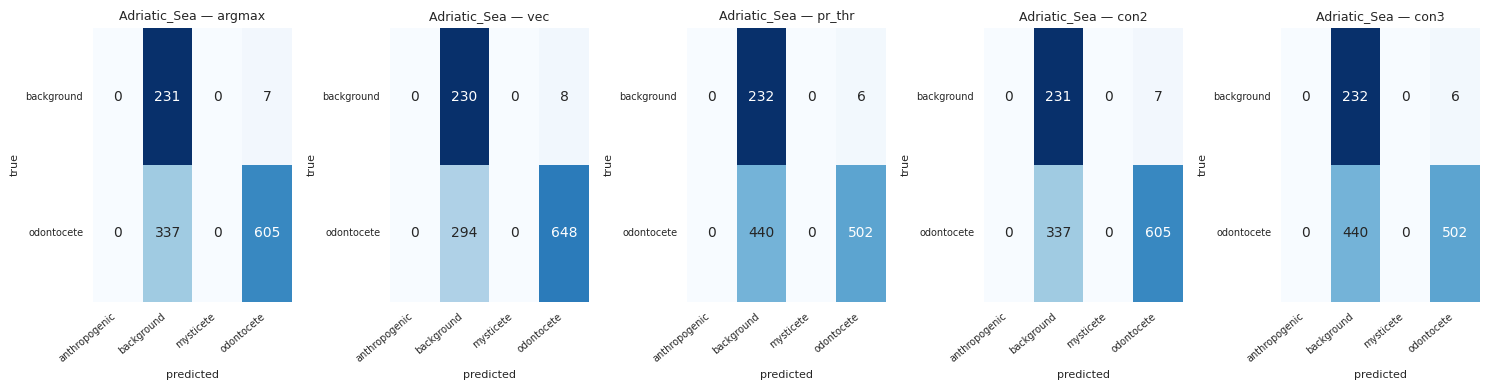


  DCLDE_2026  |  classes: ['background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.465     0.465     0.489     0.472     0.494
  balanced accuracy                          0.554     0.556     0.567     0.558     0.573
  --- species rows only ---             
  species recall (macro)                     0.579     0.594     0.552     0.574     0.551
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.733     0.745     0.712     0.730     0.711
  inter-species confusion                    0.009     0.012     0.005     0.009     0.004
  hallucination rate                         0.009     0.012     0.005     0.009     0.004


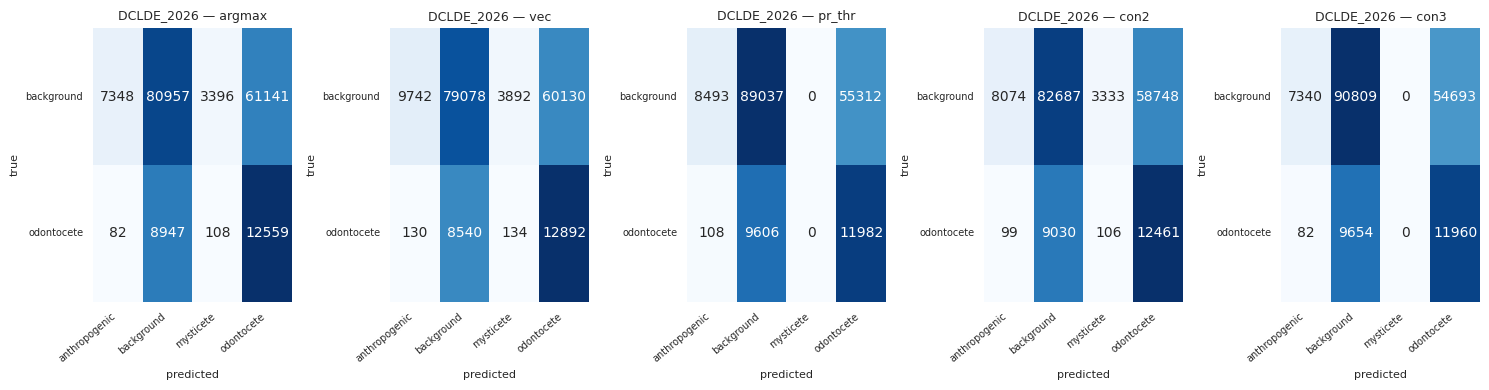


  DOLPHINFREE  |  classes: ['background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.765     0.731     0.803     0.765     0.803
  balanced accuracy                          0.797     0.773     0.823     0.797     0.823
  --- species rows only ---             
  species recall (macro)                     0.955     0.965     0.929     0.955     0.929
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.977     0.982     0.963     0.977     0.963
  inter-species confusion                    0.003     0.003     0.003     0.003     0.003
  hallucination rate                         0.003     0.003     0.003     0.003     0.003


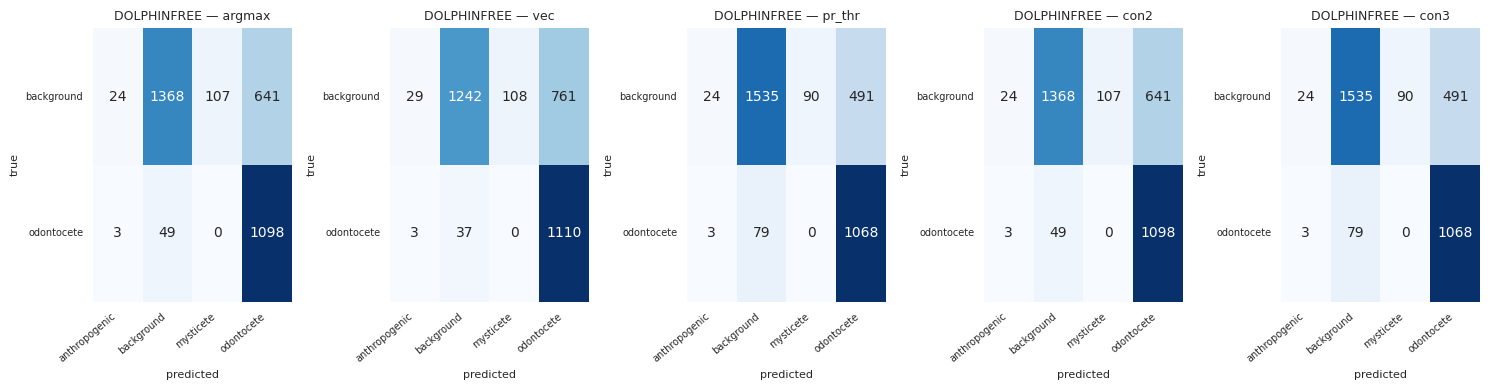


  DRYAD  |  classes: ['background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.726     0.706     0.755     0.726     0.755
  balanced accuracy                          0.729     0.713     0.751     0.729     0.751
  --- species rows only ---             
  species recall (macro)                     0.843     0.858     0.800     0.843     0.800
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.915     0.923     0.889     0.915     0.889
  inter-species confusion                    0.069     0.069     0.060     0.068     0.060
  hallucination rate                         0.069     0.069     0.060     0.068     0.060


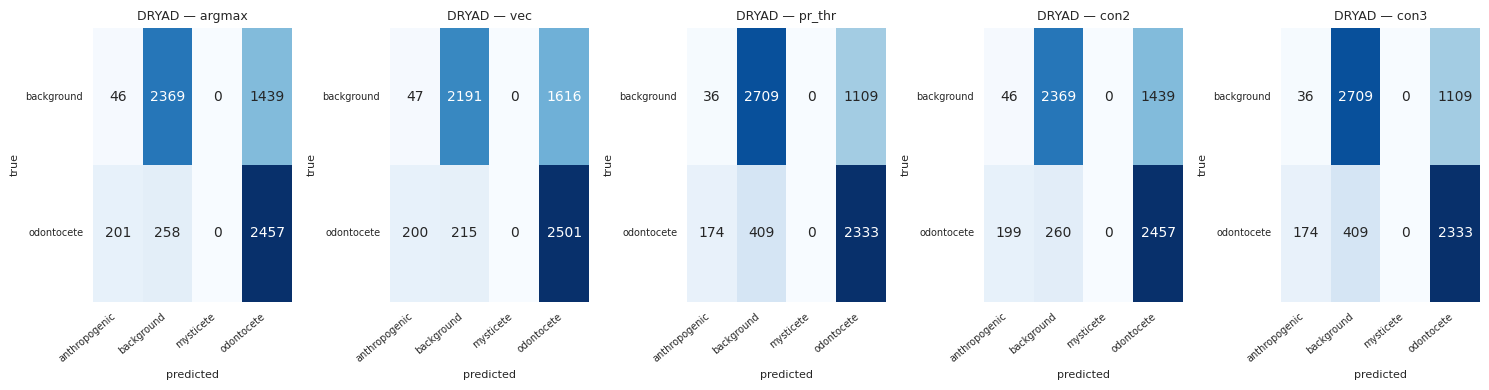


  ECOSS_annot  |  classes: ['anthropogenic', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.177     0.182     0.186     0.177     0.186
  balanced accuracy                          0.141     0.158     0.133     0.141     0.133
  --- species rows only ---             
  species recall (macro)                     0.141     0.158     0.133     0.141     0.133
  species precision (macro)                  0.238     0.216     0.307     0.238     0.307
  species macro F1                           0.177     0.182     0.186     0.177     0.186
  inter-species confusion                    0.199     0.265     0.108     0.199     0.108
  hallucination rate                         0.008     0.008     0.004     0.008     0.004


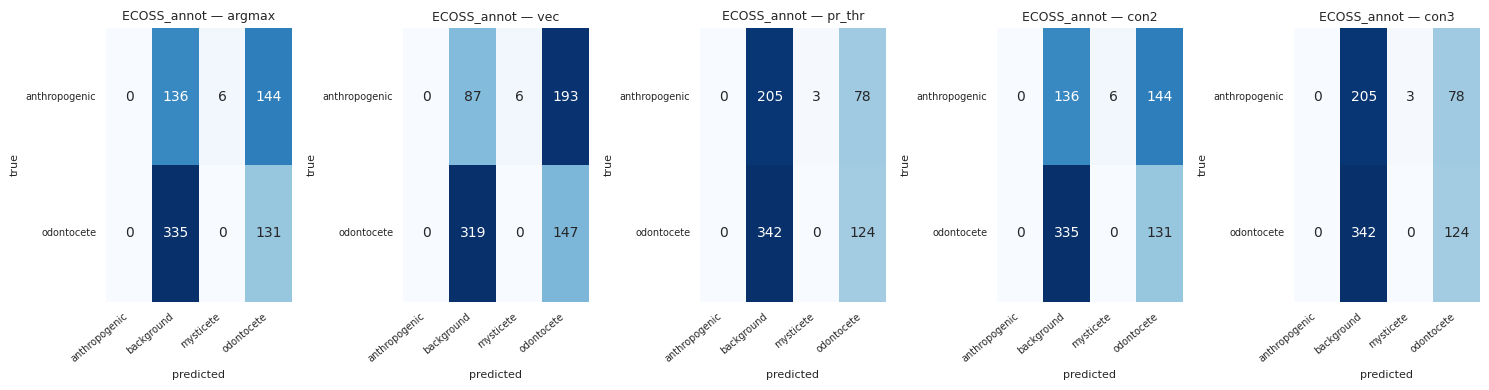


  ECOSS_testtrain  |  classes: ['anthropogenic', 'background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.066     0.054     0.082     0.066     0.082
  balanced accuracy                          0.570     0.559     0.561     0.570     0.561
  --- species rows only ---             
  species recall (macro)                     0.433     0.449     0.406     0.433     0.406
  species precision (macro)                  0.527     0.504     0.547     0.527     0.547
  species macro F1                           0.052     0.009     0.085     0.052     0.085
  inter-species confusion                    0.057     0.381     0.029     0.057     0.029
  hallucination rate                         0.001     0.001     0.000     0.001     0.000


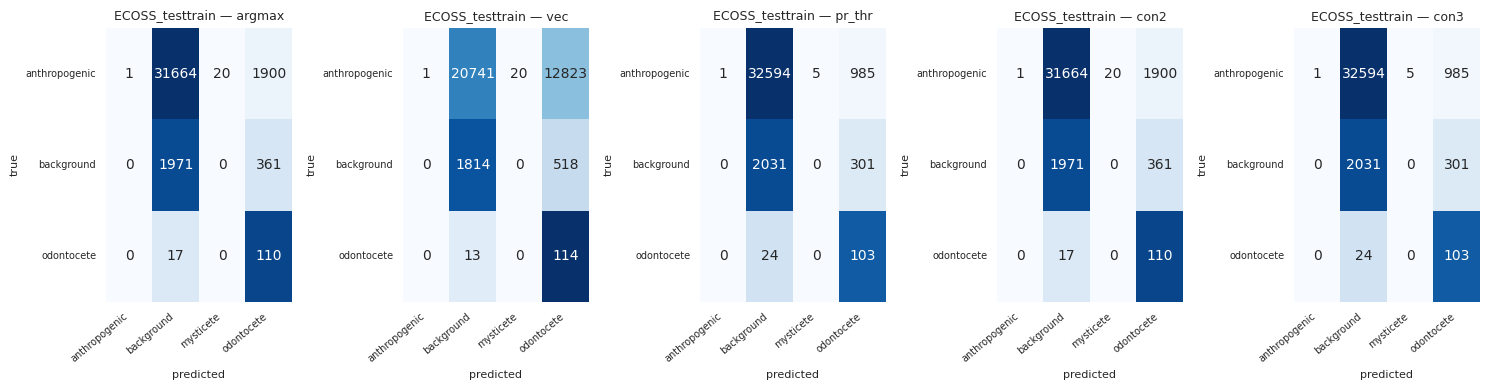


  MONISH  |  classes: ['mysticete', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.400     0.416     0.376     0.401     0.376
  balanced accuracy                          0.344     0.366     0.309     0.344     0.309
  --- species rows only ---             
  species recall (macro)                     0.344     0.366     0.309     0.344     0.309
  species precision (macro)                  0.480     0.480     0.481     0.481     0.481
  species macro F1                           0.400     0.416     0.376     0.401     0.376
  inter-species confusion                    0.133     0.136     0.092     0.131     0.092
  hallucination rate                         0.104     0.105     0.070     0.104     0.070


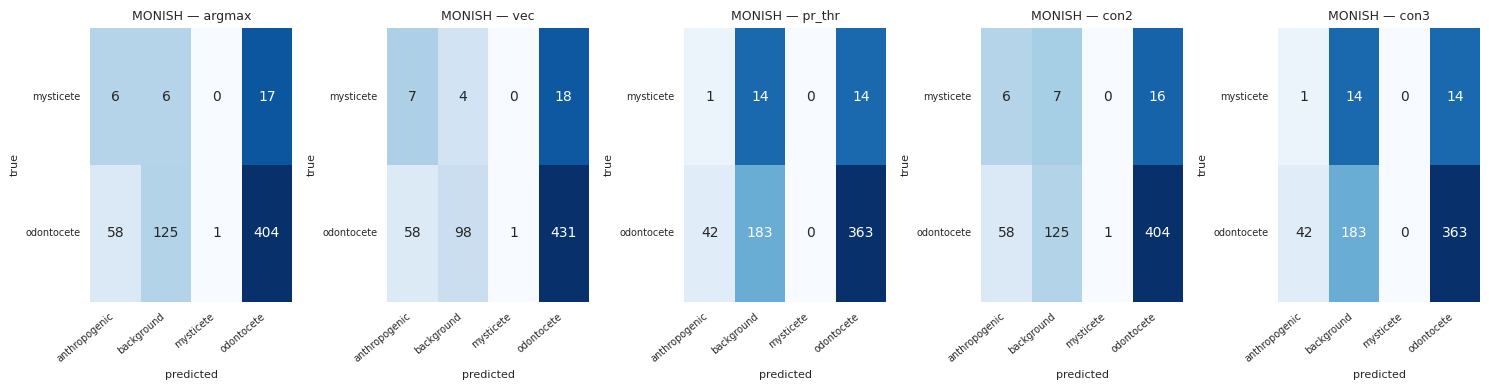


  OLTREMARE  |  classes: ['background', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.811     0.795     0.817     0.811     0.817
  balanced accuracy                          0.798     0.807     0.792     0.798     0.792
  --- species rows only ---             
  species recall (macro)                     0.647     0.699     0.621     0.647     0.621
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.786     0.823     0.766     0.786     0.766
  inter-species confusion                    0.000     0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000     0.000


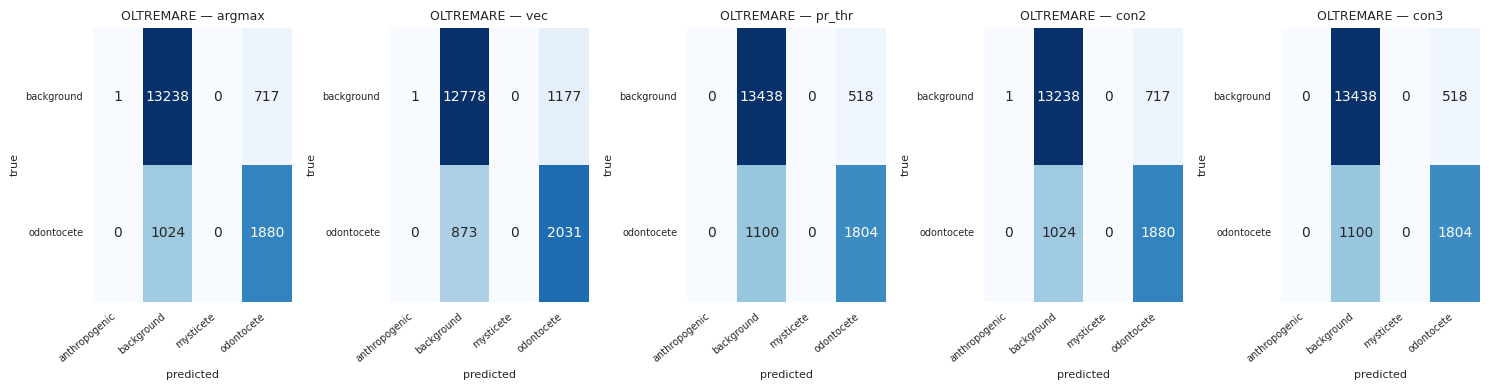


  WATKINS  |  classes: ['mysticete', 'odontocete']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.413     0.436     0.392     0.413     0.392
  balanced accuracy                          0.352     0.386     0.323     0.352     0.323
  --- species rows only ---             
  species recall (macro)                     0.352     0.386     0.323     0.352     0.323
  species precision (macro)                  0.500     0.500     0.500     0.500     0.500
  species macro F1                           0.413     0.436     0.392     0.413     0.392
  inter-species confusion                    0.278     0.292     0.005     0.271     0.005
  hallucination rate                         0.277     0.291     0.005     0.270     0.005


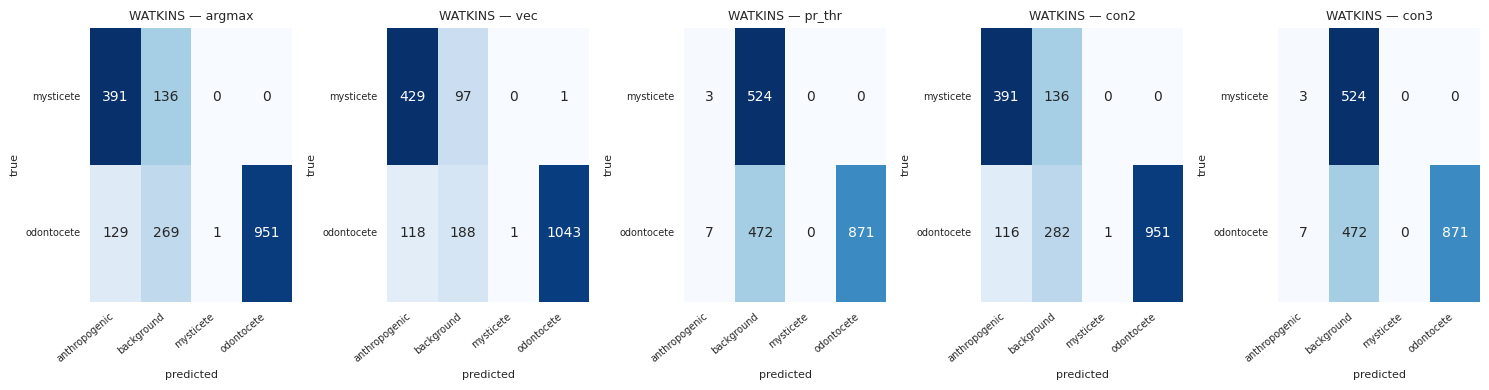

In [13]:
for ds, r in results_l2.items():
    report_fold(r, bg_label='background')

In [14]:
summary_l2 = make_summary_df(results_l2, 'L2-coarse')
print(summary_l2[[
    'held_out','n_test','n_classes_test',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall','con2_sp_recall','con3_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec','con2_sp_prec','con3_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1','con2_sp_f1','con3_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin','con2_hallucin','con3_hallucin',
]].to_string(index=False))
summary_l2.to_csv(OUT_DIR / 'summary_l2.csv', index=False)

       held_out  n_test  n_classes_test  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  con2_sp_recall  con3_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  con2_sp_prec  con3_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  con2_sp_f1  con3_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin  con2_hallucin  con3_hallucin
    DOLPHINFREE    3290               2          0.954783       0.965217             0.928696        0.954783        0.928696        1.000000     1.000000           1.000000      1.000000      1.000000      0.976868   0.982301         0.963030    0.976868    0.963030         0.002609      0.002609            0.002609       0.002609       0.002609
          DRYAD    6770               2          0.842593       0.857682             0.800069        0.842593        0.800069        1.000000     1.000000           1.000000      1.000000      1.000000      0.914573   0.923389         0.888931    0.914573    0.888931         0.068930      0.068587    

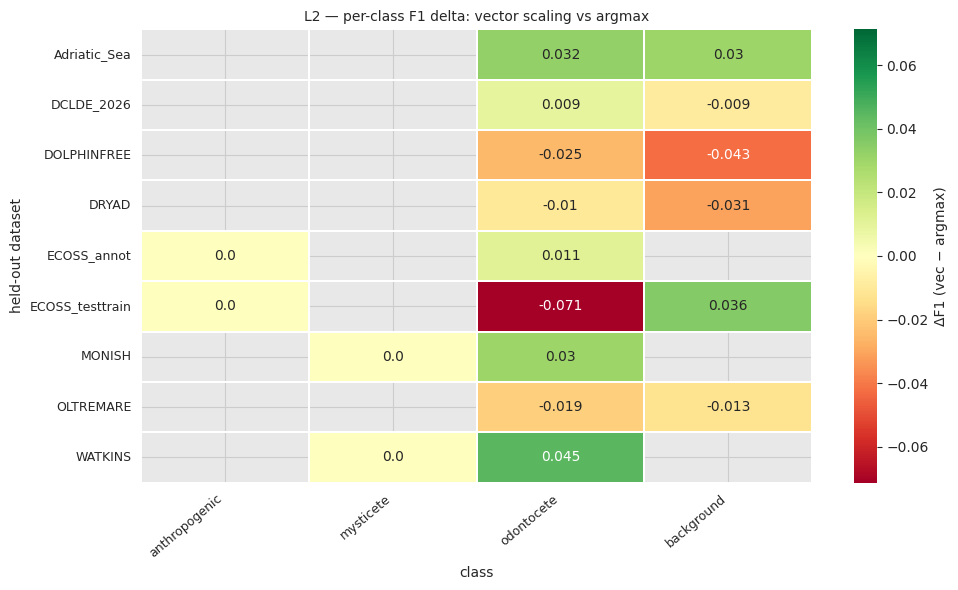


Mean ΔF1 per class (vec − argmax):
class
background      -0.005
anthropogenic    0.000
mysticete        0.000
odontocete       0.000


In [15]:
_ = per_class_delta_heatmap(
    results_l2, 'vec', 'argmax',
    title='L2 — per-class F1 delta: vector scaling vs argmax',
    out_path=OUT_DIR / 'l2_vec_delta_heatmap.png',
    bg_label='background'
)

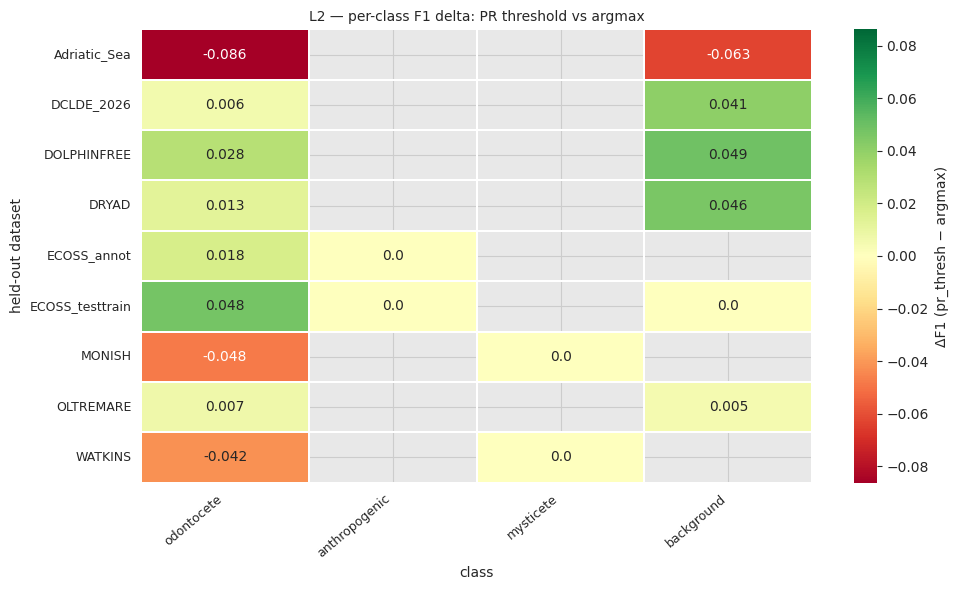


Mean ΔF1 per class (pr_thresh − argmax):
class
odontocete      -0.006
anthropogenic    0.000
mysticete        0.000
background       0.013


In [16]:
_ = per_class_delta_heatmap(
    results_l2, 'pr_thresh', 'argmax',
    title='L2 — per-class F1 delta: PR threshold vs argmax',
    out_path=OUT_DIR / 'l2_pr_thresh_delta_heatmap.png',
    bg_label='background'
)


## 9. Level 4 — species LODO

86% background, 10 species. Vector scaling calibrated on species-positive
val rows only. The `w` heatmap shows how much each species was sharpened
(`w > 1`) or flattened (`w < 1`) — background should consistently show `w < 1`
and rare species should show `w > 1` if the calibration is working correctly.

In [17]:
L4_HOLDOUTS = sorted(meta_l4['dataset'].unique().tolist())
print(f"{len(L4_HOLDOUTS)} holdouts: {L4_HOLDOUTS}")
results_l4 = run_lodo_level(
    meta_l4, 'label', 'L4-species', L4_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

9 holdouts: ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']


L4-species LODO:   0%|          | 0/9 [00:00<?, ?it/s]


  [Adriatic_Sea] train classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [Adriatic_Sea] test composition:
      Tursiops_truncatus                  n=   942  (OK)
      background                          n=   238  (OK)
  [Adriatic_Sea] train=212,467  val=28,281  (sp_val=3,655)  test=1,180
  [Adriatic_Sea] vector scales:
      Balaenoptera_acutorostrata           w=+1.060  b=-0.026
      Balaenoptera_physalus                w=+1.034  b=-0.052
      Delphinidae_unknown                  w=+1.716  b=+0.279
      Delphinus_delphis                    w=+0.602  b=-0.232
      Globicephala_melas                   w=+1.109  b=+1.837
      Grampus_griseus                      w=+0.990  b=+0.058
      Orcinus_orca                         w=+0.910  b=-0.076
      Physeter_macrocephalus    


  Adriatic_Sea  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.760     0.756     0.518     0.745     0.518
  balanced accuracy                          0.824     0.844     0.695     0.838     0.695
  --- species rows only ---             
  species recall (macro)                     0.783     0.763     0.412     0.748     0.412
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.879     0.866     0.583     0.856     0.583
  inter-species confusion                    0.023     0.010     0.001     0.008     0.001
  hallucination rate                         0.023     0.010     0.001     0.008     0.001


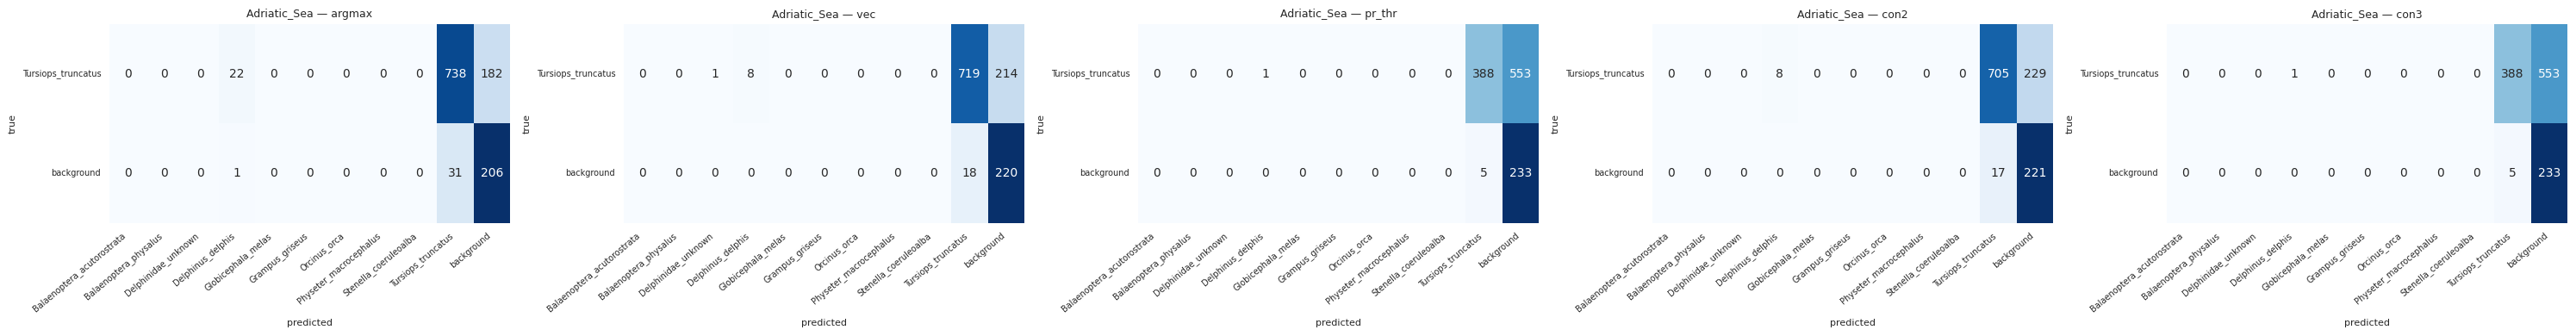


  DCLDE_2026  |  classes: ['Orcinus_orca', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.440     0.105     0.489     0.432     0.490
  balanced accuracy                          0.344     0.066     0.466     0.344     0.469
  --- species rows only ---             
  species recall (macro)                     0.143     0.100     0.039     0.087     0.038
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.250     0.182     0.074     0.160     0.074
  inter-species confusion                    0.579     0.892     0.432     0.529     0.411
  hallucination rate                         0.579     0.892     0.432     0.529     0.411


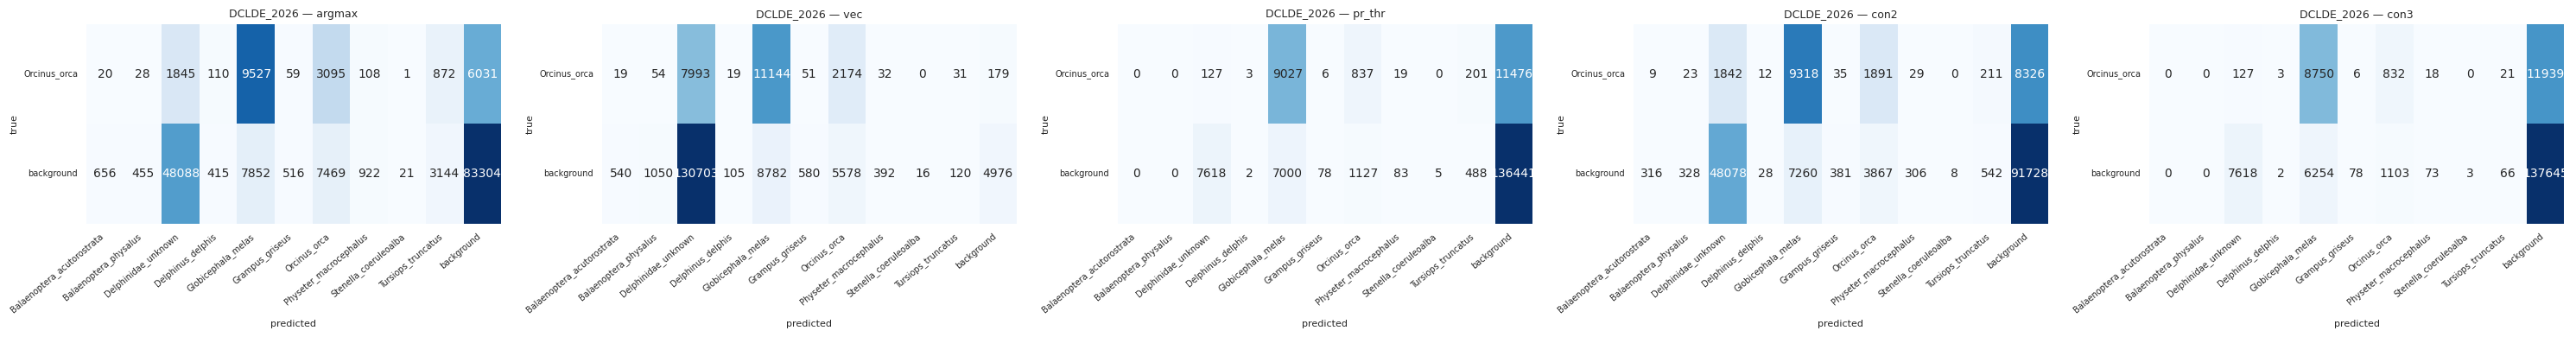


  DOLPHINFREE  |  classes: ['Delphinus_delphis', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.440     0.389     0.412     0.402     0.413
  balanced accuracy                          0.359     0.323     0.477     0.363     0.477
  --- species rows only ---             
  species recall (macro)                     0.062     0.012     0.004     0.012     0.004
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.116     0.024     0.009     0.024     0.009
  inter-species confusion                    0.823     0.903     0.295     0.771     0.295
  hallucination rate                         0.823     0.903     0.295     0.771     0.295


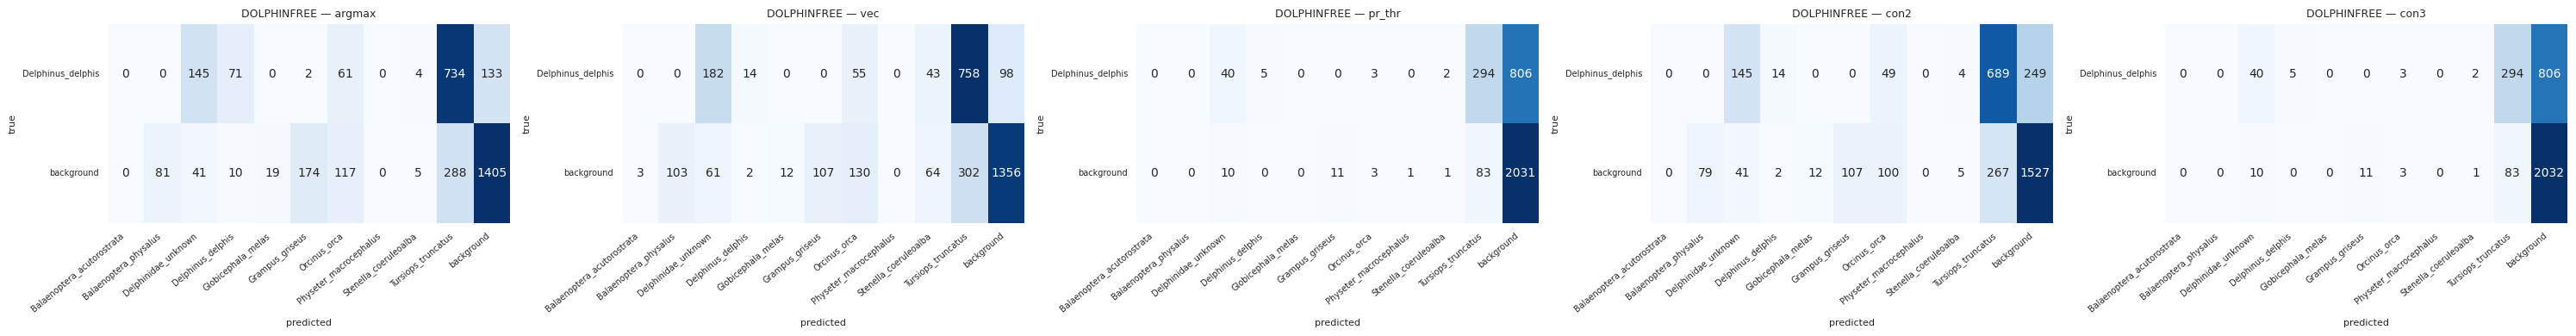


  DRYAD  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.706     0.684     0.682     0.699     0.682
  balanced accuracy                          0.666     0.643     0.672     0.661     0.672
  --- species rows only ---             
  species recall (macro)                     0.655     0.665     0.427     0.642     0.427
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.791     0.799     0.598     0.782     0.598
  inter-species confusion                    0.182     0.203     0.056     0.167     0.055
  hallucination rate                         0.182     0.203     0.056     0.167     0.055


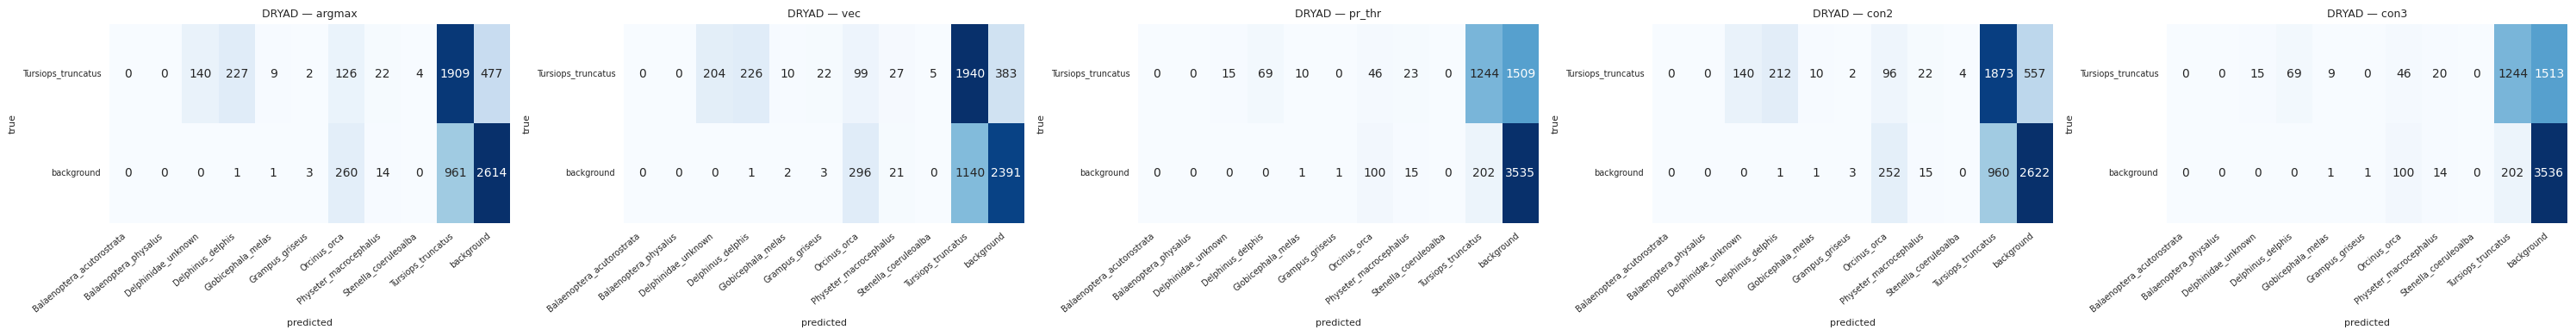


  ECOSS_annot  |  classes: ['background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.625     0.261     0.954     0.818     0.960
  balanced accuracy                          0.455     0.150     0.913     0.692     0.923
  --- species rows only ---             


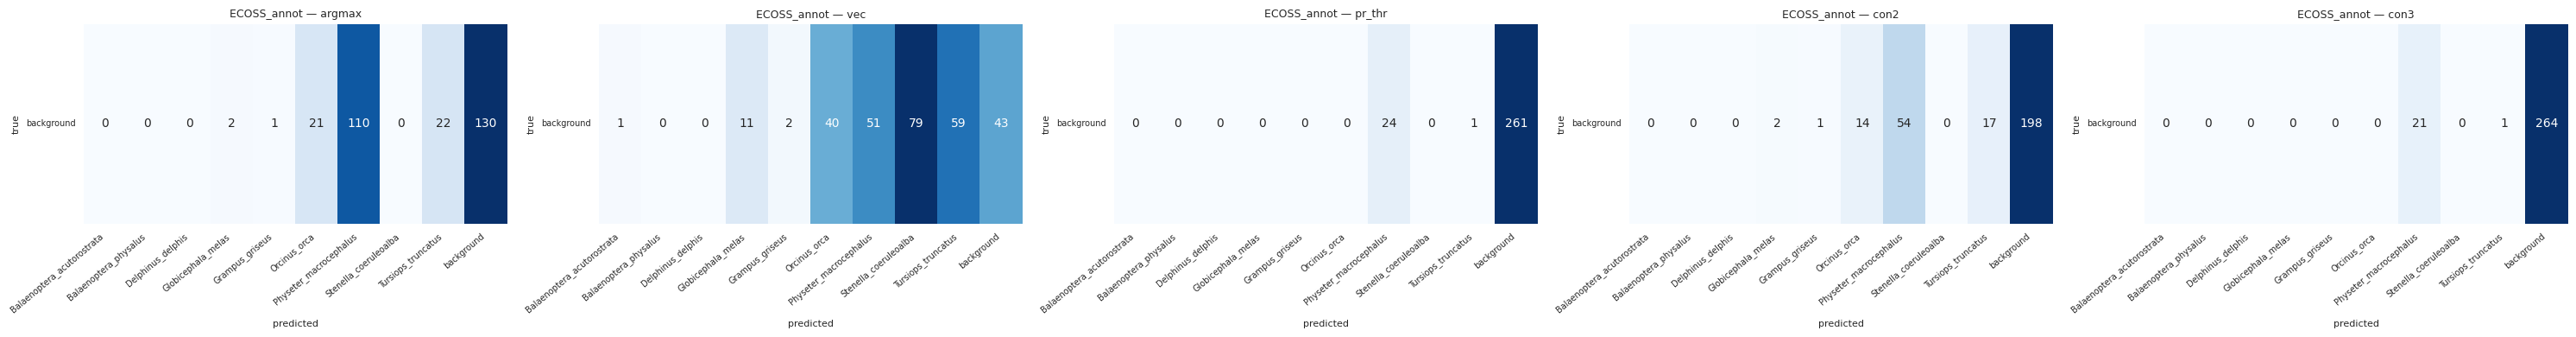


  ECOSS_testtrain  |  classes: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.233     0.202     0.330     0.341     0.311
  balanced accuracy                          0.529     0.349     0.418     0.517     0.350
  --- species rows only ---             
  species recall (macro)                     0.444     0.371     0.302     0.426     0.220
  species precision (macro)                  0.556     0.423     0.438     0.585     0.460
  species macro F1                           0.339     0.339     0.258     0.361     0.197
  inter-species confusion                    0.528     0.638     0.213     0.370     0.142
  hallucination rate                         0.016     0.283     0.000     0.

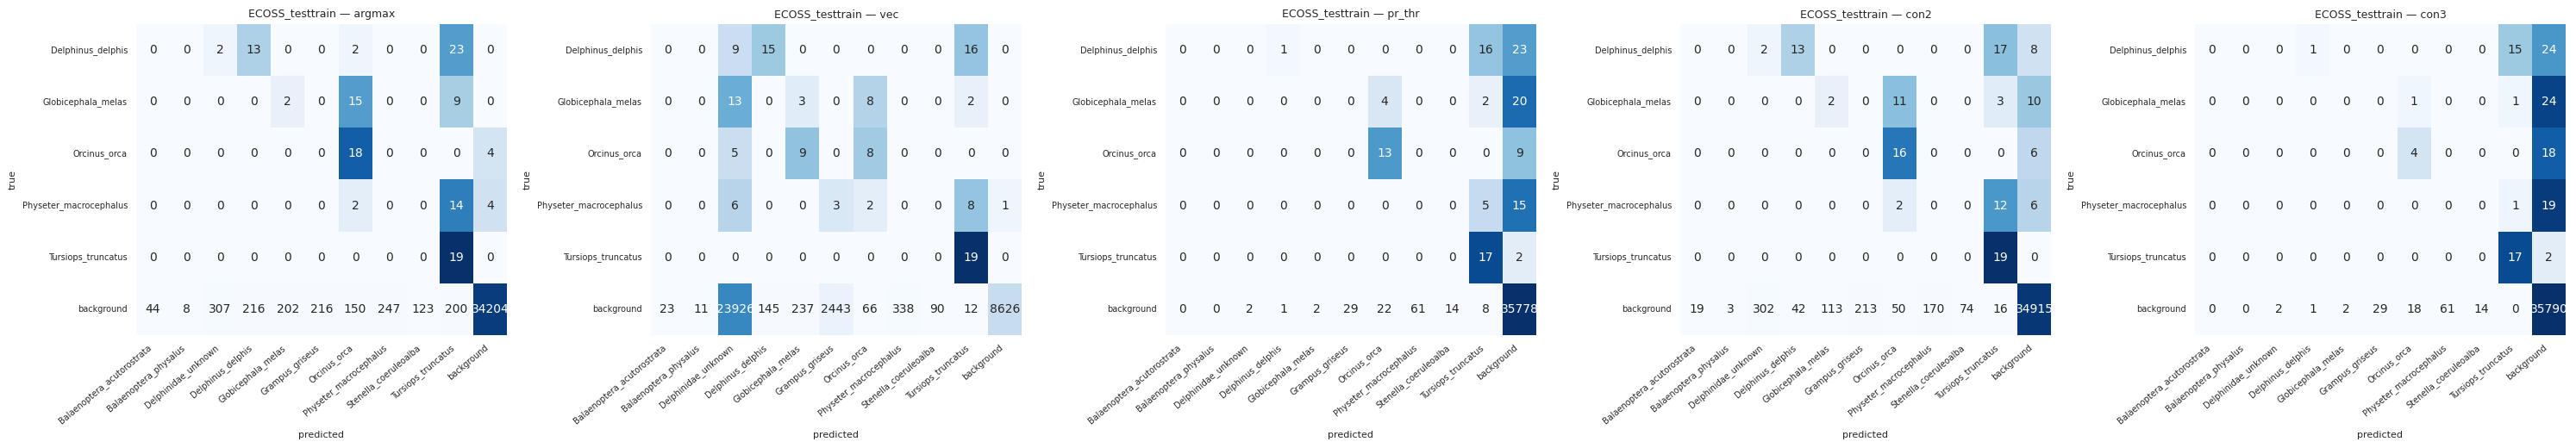


  MONISH  |  classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.132     0.137     0.105     0.130     0.104
  balanced accuracy                          0.176     0.185     0.119     0.175     0.118
  --- species rows only ---             
  species recall (macro)                     0.176     0.185     0.119     0.175     0.118
  species precision (macro)                  0.208     0.200     0.228     0.205     0.226
  species macro F1                           0.132     0.137     0.105     0.130     0.104
  inter-species confusion                    0.571     0.603     0.334     0.553     0.313
  hallucination rate                         0.063     0.065     0.044     0.052     0.026


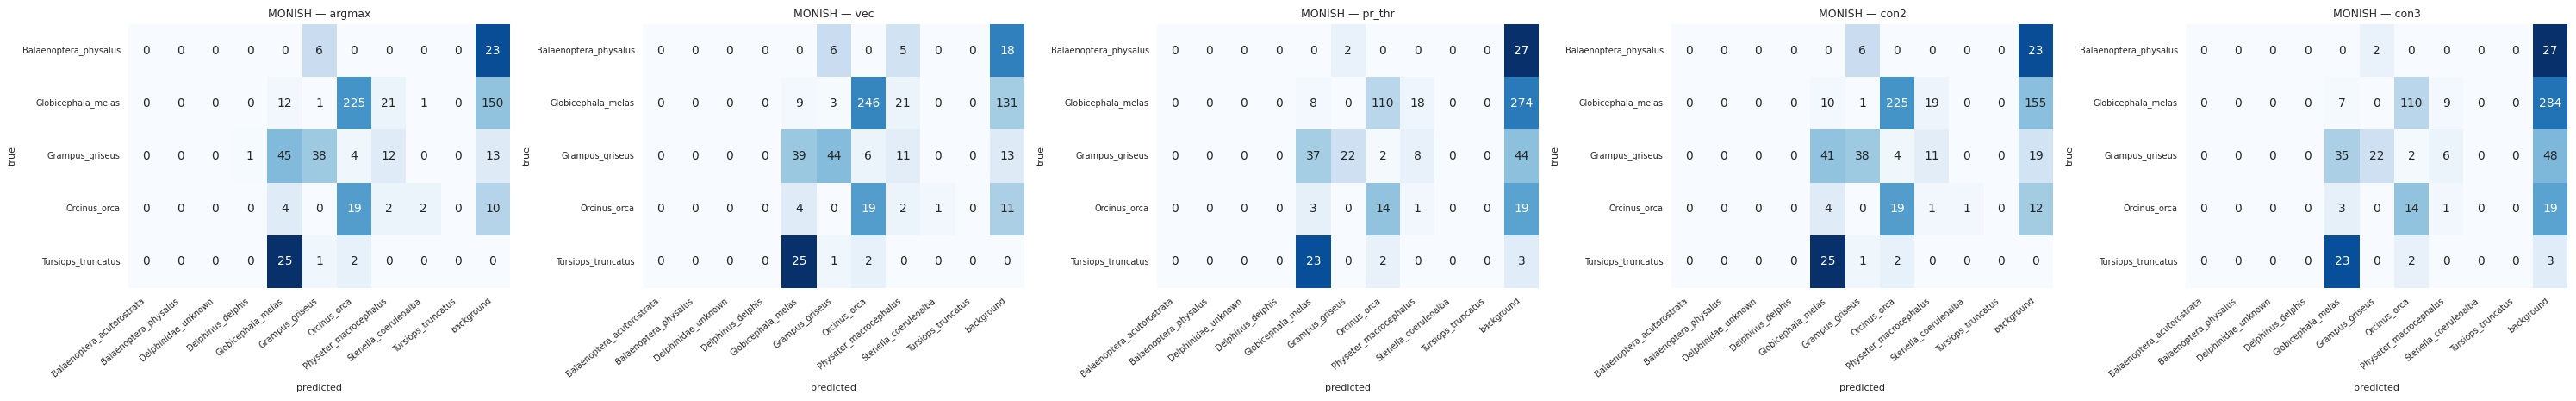


  OLTREMARE  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.823     0.810     0.816     0.823     0.816
  balanced accuracy                          0.795     0.797     0.766     0.795     0.766
  --- species rows only ---             
  species recall (macro)                     0.653     0.689     0.555     0.652     0.555
  species precision (macro)                  1.000     1.000     1.000     1.000     1.000
  species macro F1                           0.790     0.816     0.714     0.789     0.714
  inter-species confusion                    0.031     0.042     0.012     0.030     0.012
  hallucination rate                         0.031     0.042     0.012     0.030     0.012


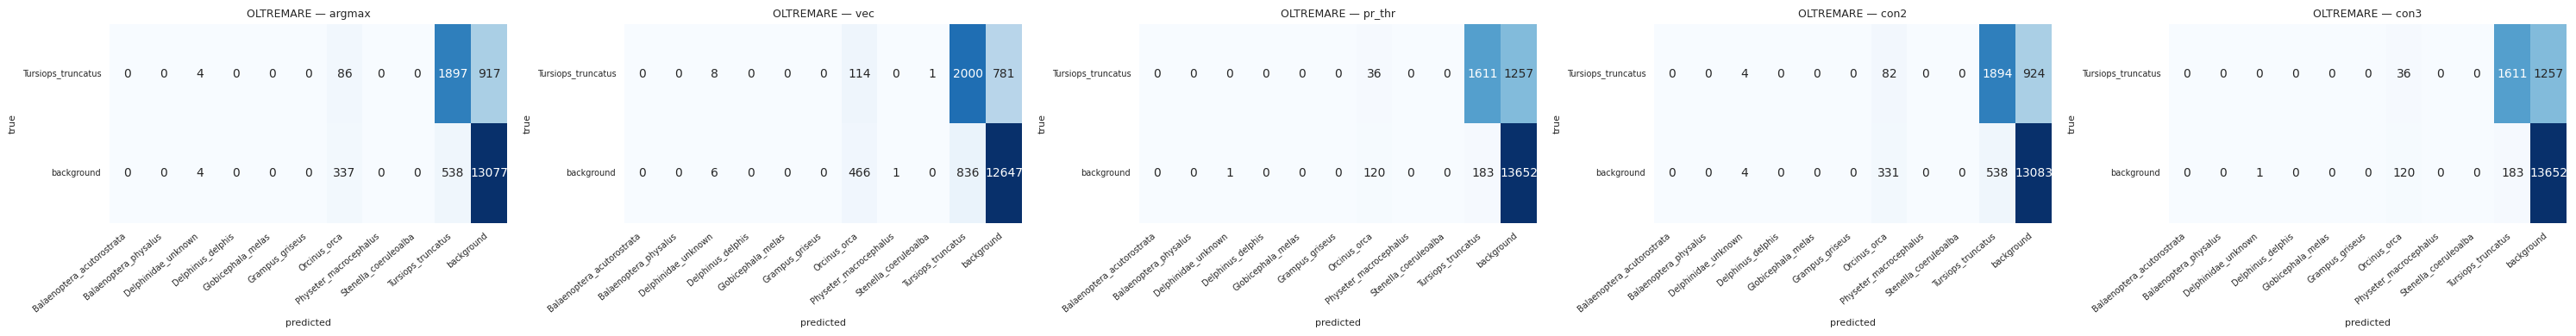


  WATKINS  |  classes: ['Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus']
  metric                                    argmax       vec    pr_thr      con2      con3
  ----------------------------------------------------------------------------------------
  macro F1 (test classes)                    0.123     0.119     0.146     0.121     0.146
  balanced accuracy                          0.395     0.386     0.200     0.384     0.200
  --- species rows only ---             
  species recall (macro)                     0.395     0.386     0.200     0.384     0.200
  species precision (macro)                  0.221     0.217     0.163     0.220     0.163
  species macro F1                           0.123     0.119     0.146     0.121     0.146
  inter-species confusion                    0.536     0.537     0.074     0.519     0.074
  hallucination rate                         0.000     

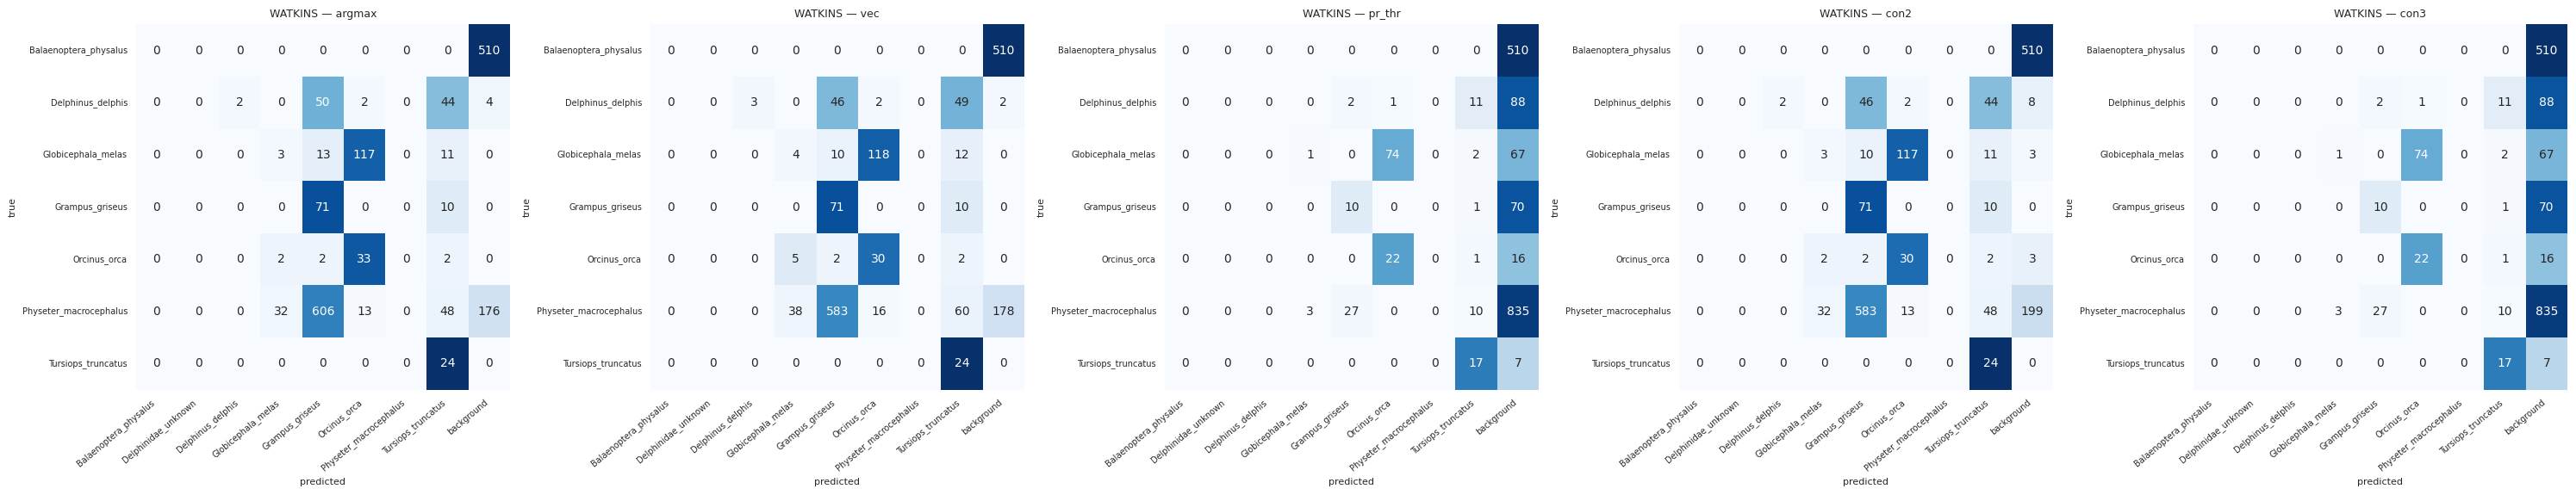

In [18]:
for ds, r in results_l4.items():
    report_fold(r, bg_label='background')

In [19]:
summary_l4 = make_summary_df(results_l4, 'L4-species')
print('\nLevel 4 — species-only metrics (all strategies):')
print(summary_l4[[
    'held_out','n_test','n_classes_test','sp_n_rows',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall','con2_sp_recall','con3_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec','con2_sp_prec','con3_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1','con2_sp_f1','con3_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin','con2_hallucin','con3_hallucin',
]].to_string(index=False))
summary_l4.to_csv(OUT_DIR / 'summary_l4.csv', index=False)


Level 4 — species-only metrics (all strategies):
       held_out  n_test  n_classes_test  sp_n_rows  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  con2_sp_recall  con3_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  con2_sp_prec  con3_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  con2_sp_f1  con3_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin  con2_hallucin  con3_hallucin
      OLTREMARE   16860               2     2904.0          0.653237       0.688705             0.554752        0.652204        0.554752        1.000000     1.000000           1.000000      1.000000      1.000000      0.790252   0.815661         0.713621    0.789496    0.713621         0.030992      0.042355            0.012397       0.029614       0.012397
          DRYAD    6770               2     2916.0          0.654664       0.665295             0.426612        0.642318        0.426612        1.000000     1.000000           1.000000      1.000000      1.000000      0.791295   0

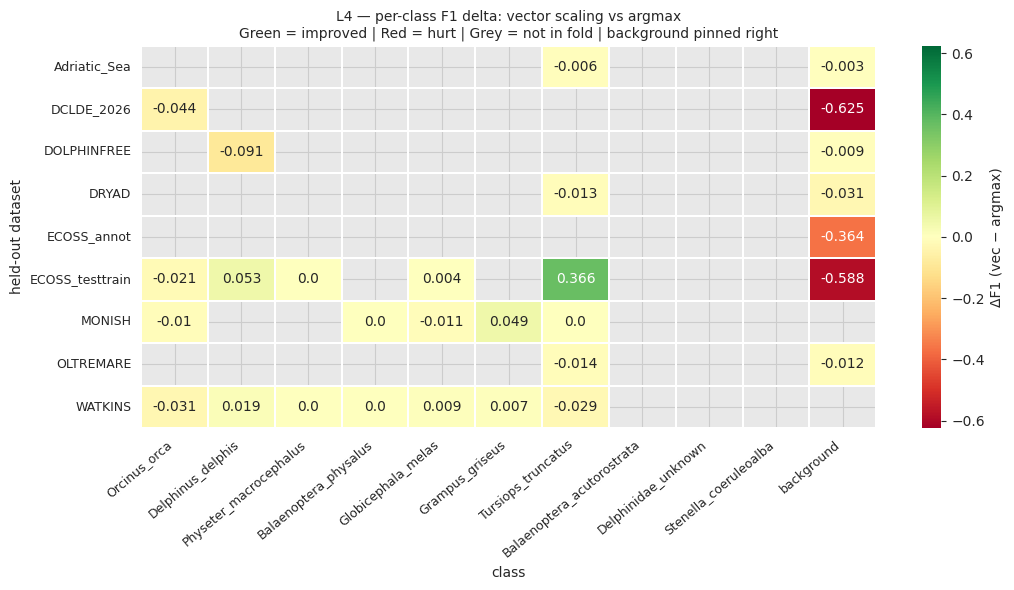


Mean ΔF1 per class (vec − argmax):
class
background                   -0.233
Orcinus_orca                 -0.027
Delphinus_delphis            -0.006
Physeter_macrocephalus        0.000
Balaenoptera_physalus         0.000
Globicephala_melas            0.001
Grampus_griseus               0.028
Tursiops_truncatus            0.051
Balaenoptera_acutorostrata      NaN
Delphinidae_unknown             NaN
Stenella_coeruleoalba           NaN


In [20]:
_ = per_class_delta_heatmap(
    results_l4, 'vec', 'argmax',
    title='L4 — per-class F1 delta: vector scaling vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_vec_delta_heatmap.png',
    bg_label='background'
)

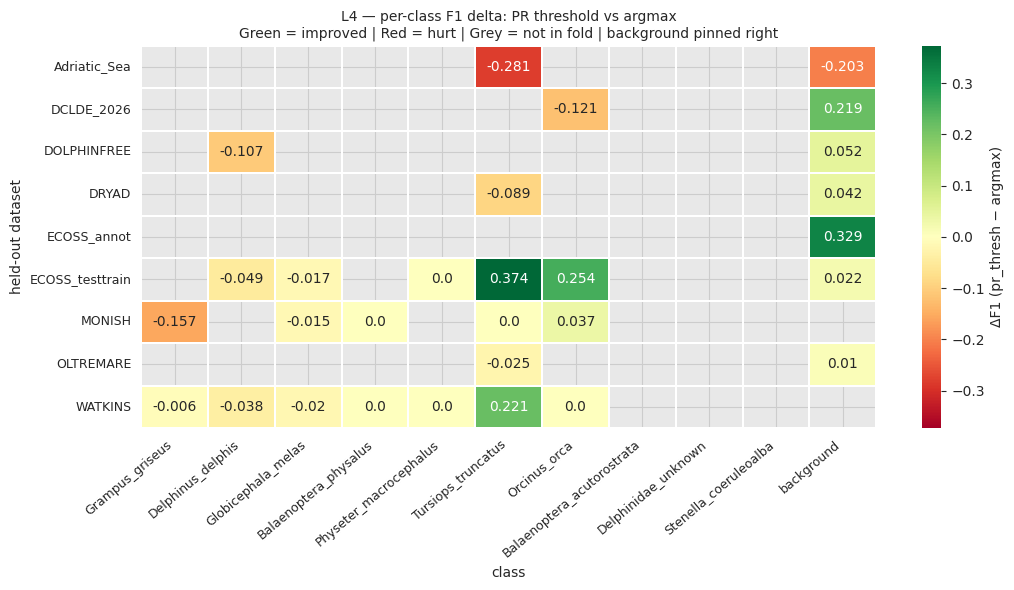


Mean ΔF1 per class (pr_thresh − argmax):
class
Grampus_griseus              -0.081
Delphinus_delphis            -0.065
Globicephala_melas           -0.017
Balaenoptera_physalus         0.000
Physeter_macrocephalus        0.000
Tursiops_truncatus            0.033
Orcinus_orca                  0.043
background                    0.067
Balaenoptera_acutorostrata      NaN
Delphinidae_unknown             NaN
Stenella_coeruleoalba           NaN


In [21]:
_ = per_class_delta_heatmap(
    results_l4, 'pr_thresh', 'argmax',
    title='L4 — per-class F1 delta: PR threshold vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_pr_thresh_delta_heatmap.png',
    bg_label='background'
)


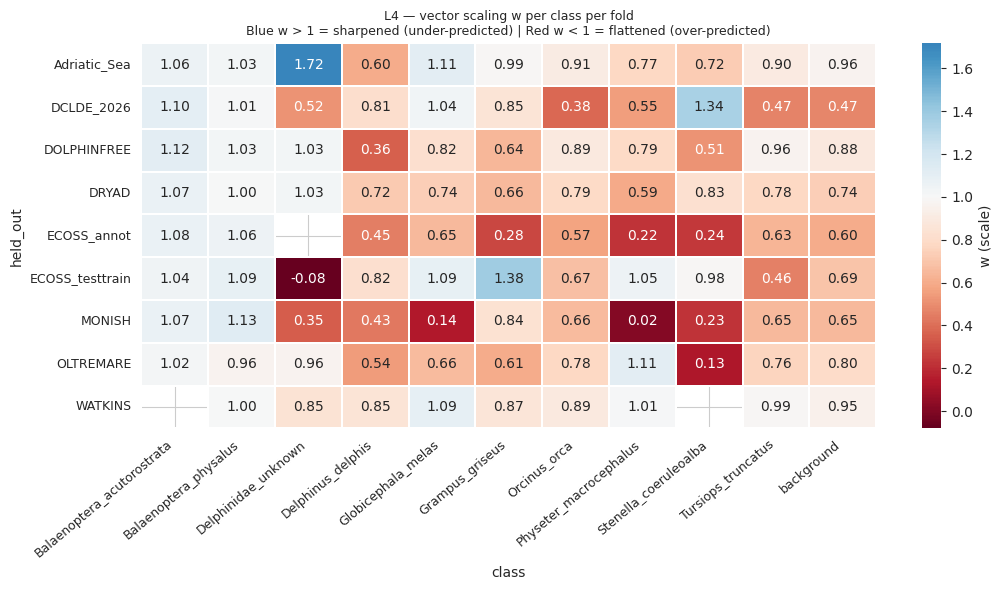

In [22]:
# ── Vector w heatmap ─────────────────────────────────────────────────────────
w_rows = []
for ds, r in results_l4.items():
    for c_name, w_val in zip(r['class_names'], r['vec_w']):
        w_rows.append({'held_out': ds, 'class': c_name, 'w': float(w_val)})

w_pivot = pd.DataFrame(w_rows).pivot(index='held_out', columns='class', values='w')
sp_cols = [c for c in w_pivot.columns if c != 'background']
w_pivot = w_pivot[sorted(sp_cols) + (['background'] if 'background' in w_pivot.columns else [])]

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(w_pivot.columns)+2),
                                 max(5, 0.5*len(w_pivot)+1.5)))
sns.heatmap(w_pivot, cmap='RdBu', center=1.0, annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'w (scale)'})
ax.set_title(
    'L4 — vector scaling w per class per fold\n'
    'Blue w > 1 = sharpened (under-predicted) | Red w < 1 = flattened (over-predicted)',
    fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_vec_w_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

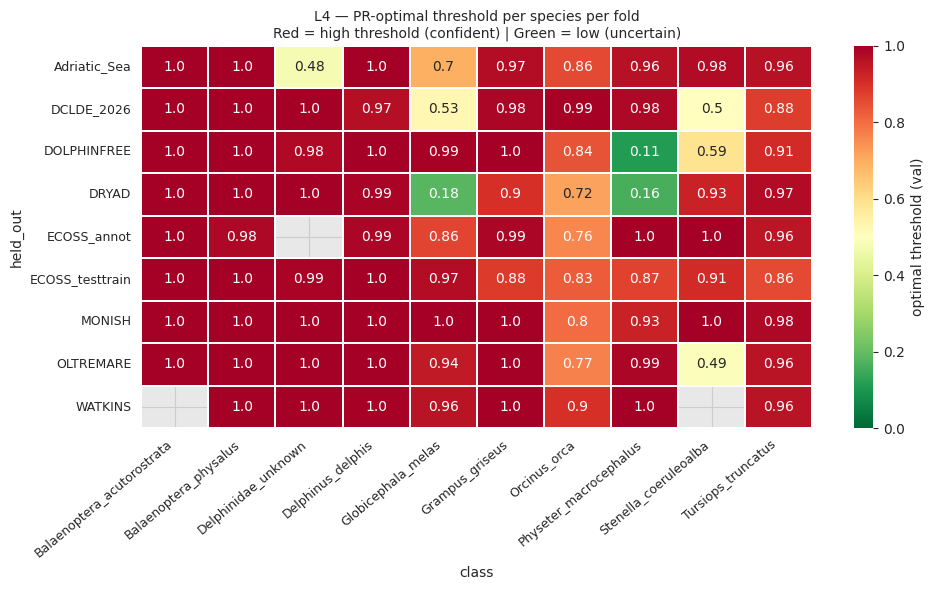

In [23]:
# ── PR threshold heatmap: what threshold was fit per species per fold ────────
thr_rows = []
for ds, r in results_l4.items():
    for cls_name, thr in r['pr_thresholds'].items():
        if cls_name == 'background': continue
        thr_rows.append({'held_out': ds, 'class': cls_name, 'threshold': thr})

thr_pivot = pd.DataFrame(thr_rows).pivot(index='held_out', columns='class', values='threshold')

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(thr_pivot.columns)+2),
                                 max(5,  0.5*len(thr_pivot)+1.5)))
sns.heatmap(thr_pivot, cmap='RdYlGn_r', vmin=0, vmax=1,
            annot=thr_pivot.round(2), fmt='', linewidths=0.3, ax=ax,
            mask=thr_pivot.isna(), cbar_kws={'label': 'optimal threshold (val)'})
ax.set_facecolor('#e8e8e8')
ax.set_title('L4 — PR-optimal threshold per species per fold\n'
             'Red = high threshold (confident) | Green = low (uncertain)',
             fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_pr_threshold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


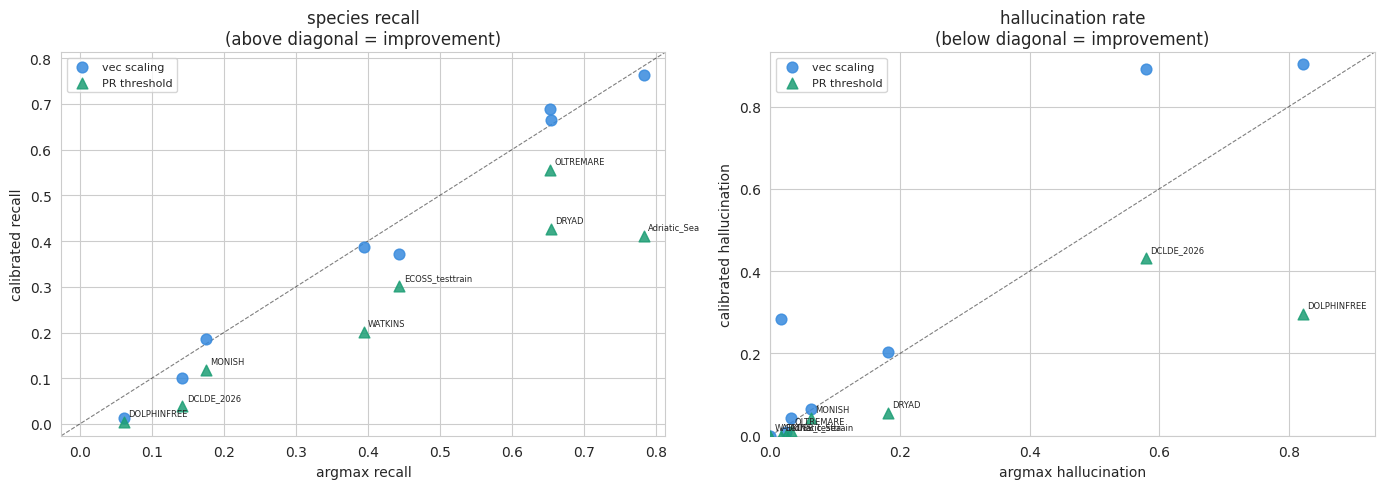

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sub = summary_l4.dropna(subset=['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall'])
lim = [min(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].min()) - 0.03,
       max(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].max()) + 0.03]
ax.scatter(sub['argmax_sp_recall'], sub['vec_sp_recall'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub['argmax_sp_recall'], sub['pr_thresh_sp_recall'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub.iterrows():
    ax.annotate(row['held_out'], (row['argmax_sp_recall'], row['pr_thresh_sp_recall']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('argmax recall'); ax.set_ylabel('calibrated recall')
ax.set_title('species recall\n(above diagonal = improvement)')
ax.legend(fontsize=8)

ax = axes[1]
sub2 = summary_l4.dropna(subset=['argmax_hallucin','vec_hallucin','pr_thresh_hallucin'])
lim2 = [0, max(sub2[['argmax_hallucin','vec_hallucin','pr_thresh_hallucin']].max()) + 0.03]
ax.scatter(sub2['argmax_hallucin'], sub2['vec_hallucin'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub2['argmax_hallucin'], sub2['pr_thresh_hallucin'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub2.iterrows():
    ax.annotate(row['held_out'], (row['argmax_hallucin'], row['pr_thresh_hallucin']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim2, lim2, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel('argmax hallucination'); ax.set_ylabel('calibrated hallucination')
ax.set_title('hallucination rate\n(below diagonal = improvement)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'recall_hallucin_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
all_summary = pd.concat([summary_l2, summary_l4], ignore_index=True)
all_summary.to_csv(OUT_DIR / 'summary_all_levels.csv', index=False)

print('Mean species metrics by level and strategy:')
rows_out = []
for level, df in [('L2', summary_l2), ('L4', summary_l4)]:
    for strat, rcol, pcol, fcol, hcol in [
        ('argmax',    'argmax_sp_recall',    'argmax_sp_prec',    'argmax_sp_f1',    'argmax_hallucin'),
        ('vec',       'vec_sp_recall',       'vec_sp_prec',       'vec_sp_f1',       'vec_hallucin'),
        ('pr_thresh', 'pr_thresh_sp_recall', 'pr_thresh_sp_prec', 'pr_thresh_sp_f1', 'pr_thresh_hallucin'),
        ('con2',      'con2_sp_recall',      'con2_sp_prec',      'con2_sp_f1',      'con2_hallucin'),
        ('con3',      'con3_sp_recall',      'con3_sp_prec',      'con3_sp_f1',      'con3_hallucin'),
    ]:
        sub = df.dropna(subset=[rcol, pcol, fcol])
        if sub.empty: continue
        row = {'level': level, 'strategy': strat,
               'mean_recall':    round(sub[rcol].mean(), 4),
               'mean_precision': round(sub[pcol].mean(), 4),
               'mean_sp_f1':     round(sub[fcol].mean(), 4)}
        if hcol:
            row['mean_hallucin'] = round(sub[hcol].dropna().mean(), 4)
        rows_out.append(row)
print(pd.DataFrame(rows_out).to_string(index=False))


Mean species metrics by level and strategy:
level  strategy  mean_recall  mean_precision  mean_sp_f1  mean_hallucin
   L2    argmax       0.5484          0.7495      0.5816         0.0522
   L2       vec       0.5737          0.7445      0.5924         0.0543
   L2 pr_thresh       0.5117          0.7595      0.5627         0.0163
   L2      con2       0.5479          0.7496      0.5813         0.0514
   L2      con3       0.5116          0.7595      0.5626         0.0161
   L4    argmax       0.4138          0.7482      0.4275         0.2146
   L4       vec       0.3964          0.7301      0.4103         0.2997
   L4 pr_thresh       0.2572          0.7285      0.3109         0.1050
   L4      con2       0.3908          0.7513      0.4030         0.1966
   L4      con3       0.2468          0.7310      0.3031         0.1000


## 10. Persist artefacts

In [26]:
def save_preds(name, r):
    rows_te     = r.get('rows_te')
    class_names = r.get('class_names')
    if rows_te is None or class_names is None: return
    df = meta_all[meta_all['row'].isin(rows_te)].copy()
    # then reorder to match rows_te order
    row_to_pos = {r: i for i, r in enumerate(rows_te)}
    df = df.sort_values('row', key=lambda s: s.map(row_to_pos)).reset_index(drop=True)
    df['y_true']      = [class_names[i] for i in r['yte']]
    df['y_argmax']    = [class_names[i] for i in r['y_argmax']]
    df['y_vec']       = [class_names[i] for i in r['y_vec']]
    df['y_pr_thresh'] = [class_names[i] for i in r['y_pr_thresh']]
    df['y_con2']      = [class_names[i] for i in r['y_con2']]
    df['y_con3']      = [class_names[i] for i in r['y_con3']]
    for ci, cn in enumerate(class_names):
        df[f'prob_raw_{cn}'] = r['proba_raw'][:, ci]
        df[f'prob_vec_{cn}'] = r['proba_vec'][:, ci]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)
    print(f"  {fp.name}  ({len(df):,} rows)")

print('Level 2:'); [save_preds(f'l2_{ds}', r) for ds, r in results_l2.items()]
print('Level 4:'); [save_preds(f'l4_{ds}', r) for ds, r in results_l4.items()]

# save per-fold PR thresholds as JSON
all_thresholds = {ds: r['pr_thresholds'] for ds, r in results_l4.items()}
with open(OUT_DIR / 'l4_pr_thresholds_per_fold.json', 'w') as f:
    json.dump(all_thresholds, f, indent=2)
print(f'\nPR thresholds  → {OUT_DIR}/l4_pr_thresholds_per_fold.json')
print(f'All artefacts  → {OUT_DIR.resolve()}')


Level 2:
  preds_l2_Adriatic_Sea.parquet  (1,180 rows)
  preds_l2_DCLDE_2026.parquet  (174,538 rows)
  preds_l2_DOLPHINFREE.parquet  (3,290 rows)
  preds_l2_DRYAD.parquet  (6,770 rows)
  preds_l2_ECOSS_annot.parquet  (752 rows)
  preds_l2_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l2_MONISH.parquet  (617 rows)
  preds_l2_OLTREMARE.parquet  (16,860 rows)
  preds_l2_WATKINS.parquet  (1,877 rows)
Level 4:
  preds_l4_Adriatic_Sea.parquet  (1,180 rows)
  preds_l4_DCLDE_2026.parquet  (174,538 rows)
  preds_l4_DOLPHINFREE.parquet  (3,290 rows)
  preds_l4_DRYAD.parquet  (6,770 rows)
  preds_l4_ECOSS_annot.parquet  (286 rows)
  preds_l4_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l4_MONISH.parquet  (617 rows)
  preds_l4_OLTREMARE.parquet  (16,860 rows)
  preds_l4_WATKINS.parquet  (1,775 rows)

PR thresholds  → /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo_Best_version/l4_pr_thresholds_per_fold.json
All artefacts  → /data2/mromaniuc/cet-de